In [35]:
import lovelyplots
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.utils.logging_config import logger

logger.setLevel("INFO")
# logger.setLevel("DEBUG")

In [ ]:
# NOTE, this is expensive but typically you wouldn't need to built all these at once
# either turn precompute_polytope off or
# just save the circuitpolytope data and not go through the expensive build repeatedly
from gulps.isa_library.defined_isas import ISA_LIBRARY

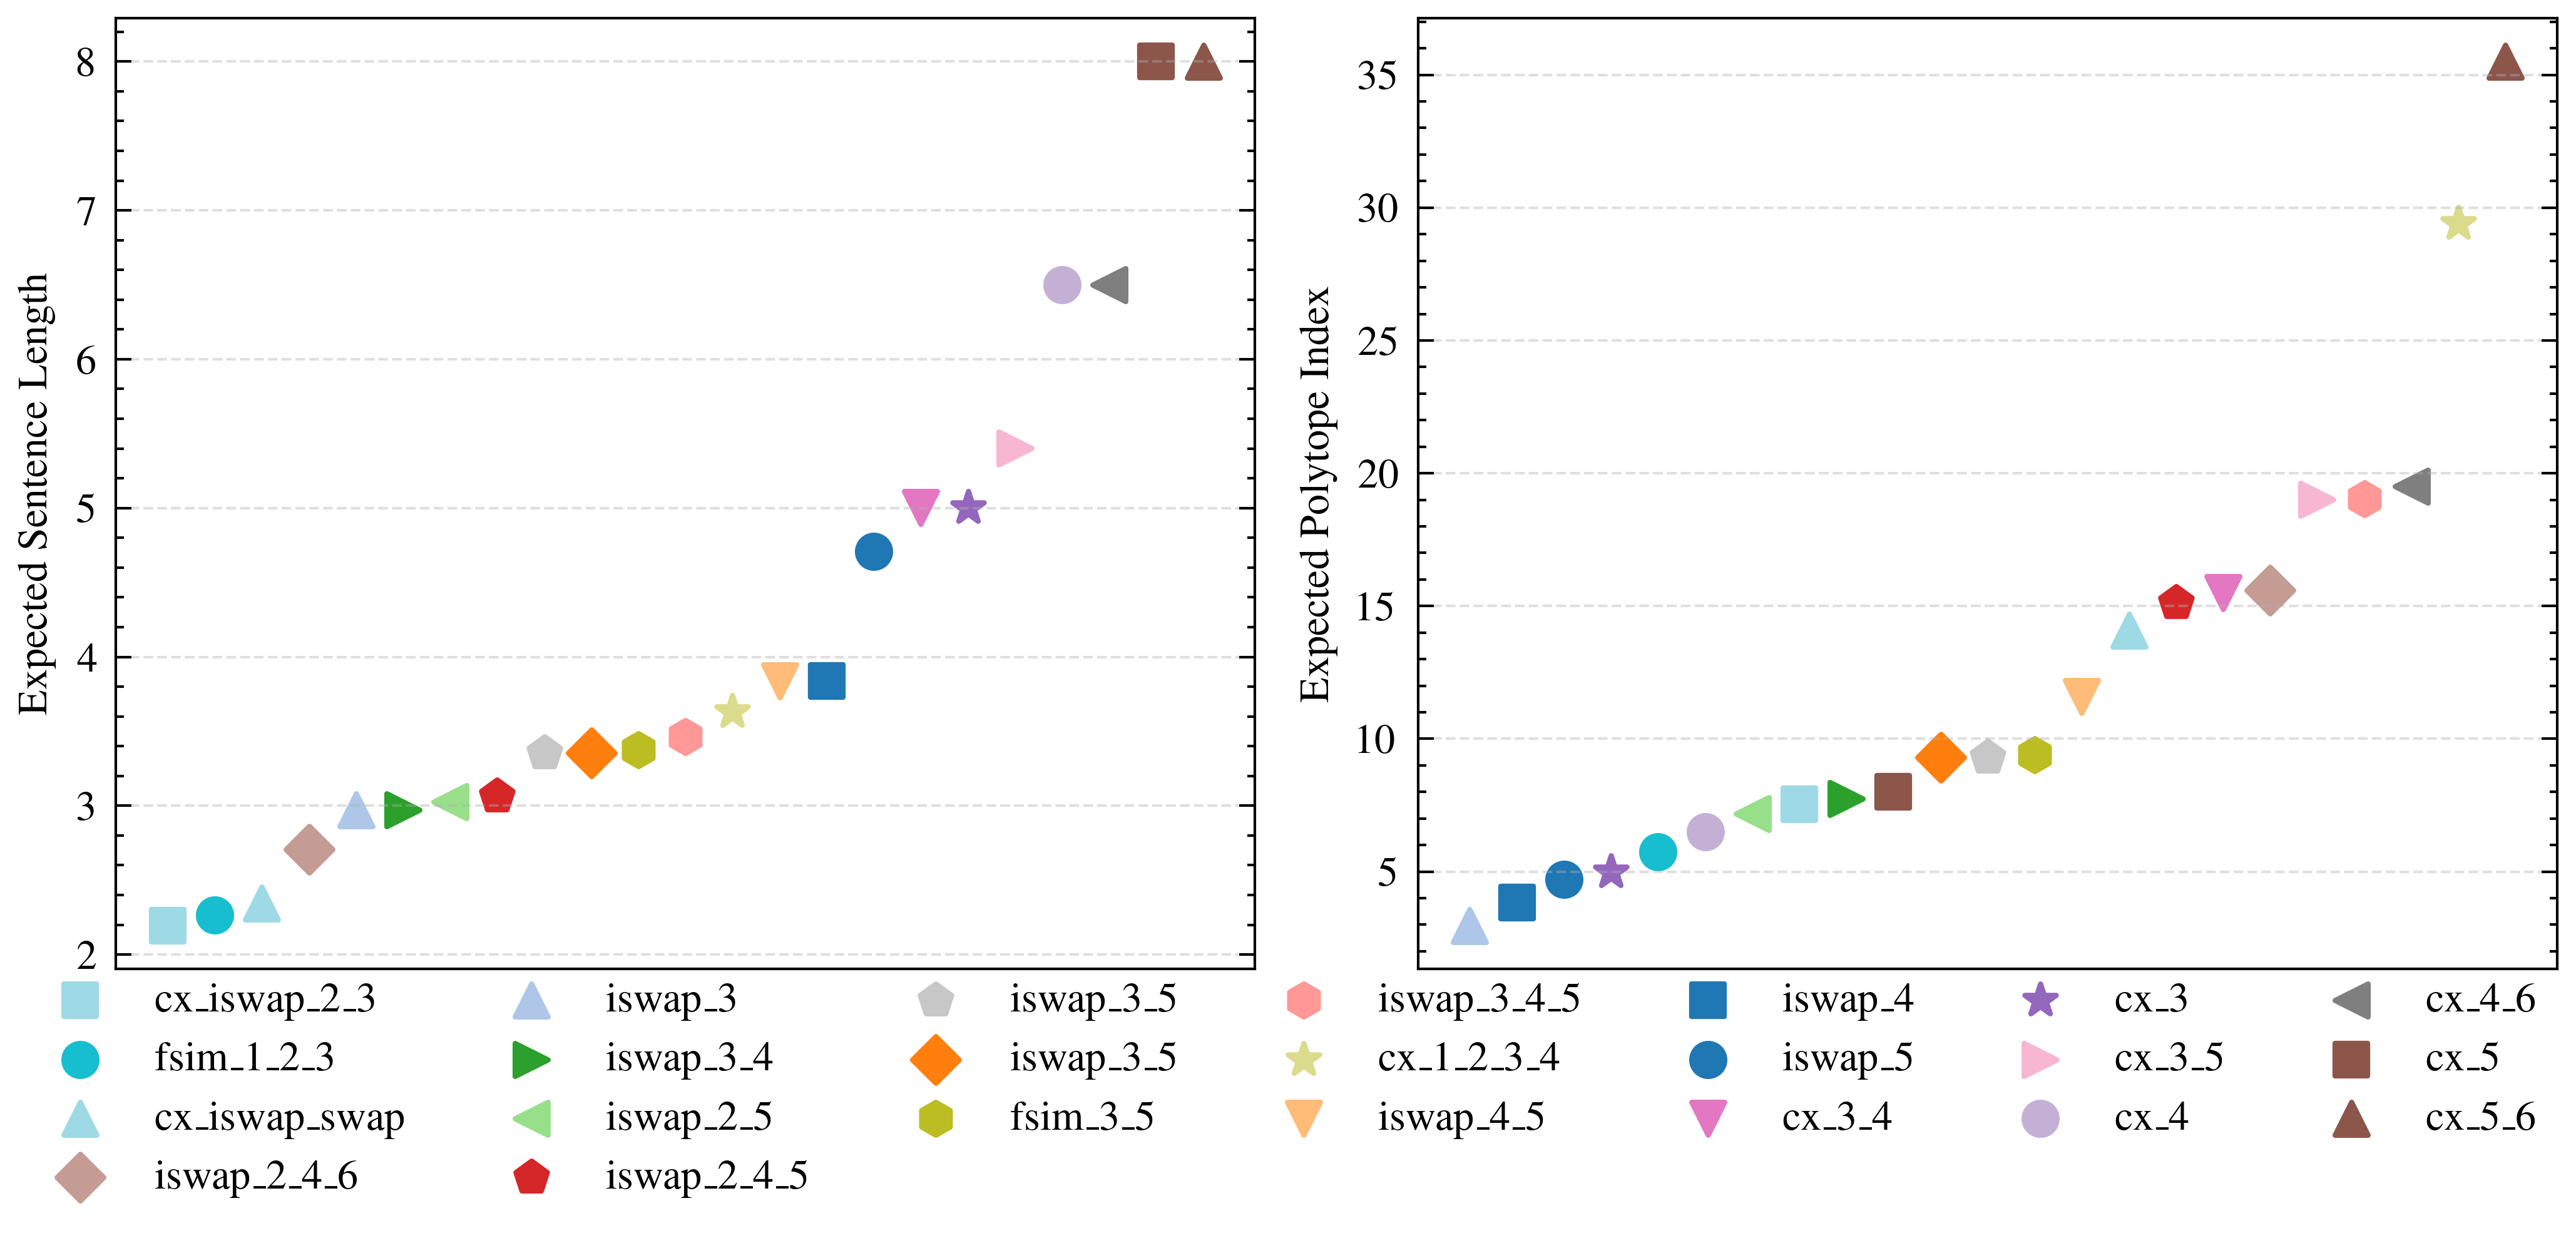

In [41]:
# === Extract ISA Benchmark Metadata ===
names = [cfg["name"] for cfg in ISA_LIBRARY]
haar = np.array([cfg["expected_cost"] for cfg in ISA_LIBRARY])
depth = np.array([cfg["expected_sentence_len"] for cfg in ISA_LIBRARY])
poly = np.array([cfg["expected_polytope_index"] for cfg in ISA_LIBRARY])

N = len(names)
colors = cm.tab20(np.linspace(0, 1, N))
markers = ["o", "s", "^", "D", "v", ">", "<", "p", "h", "*"] * ((N // 10) + 1)

sorted_depth = np.argsort(depth)
sorted_poly = np.argsort(poly)
sorted_haar = np.argsort(haar)

# === Plot Summary Metrics ===
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))

    axs = axes[0]
    for i, j in enumerate(sorted_depth):
        axs.scatter(i, depth[j], c=[colors[j]], marker=markers[j], s=40, label=names[j])
        axs.set_ylabel("Expected Sentence Length")
        axs.set_xticks([])
        axs.grid(True, axis="y", linestyle="--", alpha=0.4)

    axs = axes[1]
    for i, j in enumerate(sorted_poly):
        axs.scatter(i, poly[j], c=[colors[j]], marker=markers[j], s=40, label=names[j])
        axs.set_ylabel("Expected Polytope Index")
        axs.set_xticks([])
        axs.grid(True, axis="y", linestyle="--", alpha=0.4)

    # axs = axes[2]
    # for i,j in enumerate(sorted_haar):
    #     axs.scatter(
    #         i, haar[j], c=[colors[j]], marker=markers[j], s=40, label=names[j]
    #     )
    #     axs.set_ylabel("Expected Gate Cost")
    #     axs.set_xticks([])
    #     axs.grid(True, axis="y", linestyle="--", alpha=0.4)

    # Show global legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(names) // 3,
        bbox_to_anchor=(0.5, -0.2),
    )
    fig.tight_layout()
    plt.show()

In [ ]:
# === Run Fidelity and Timing Benchmarks ===
N = 1000  # Set to 100 for quick test or 1000 for full run
results = []

for config in ISA_LIBRARY:
    name = config["name"]
    decomposer = GulpsDecomposer(gate_set=None, costs=None, isa=config["isa"])
    fidelities, timings = [], []

    # Warm-up (trigger any internal caching paths)
    _ = decomposer._run(random_unitary(4, seed=0))

    for idx in trange(N, desc=f"Running {name}"):
        u = random_unitary(4, seed=idx)
        try:
            v = Operator(decomposer(u))
            fidelities.append(average_gate_fidelity(u, v))
            timings.append(decomposer.last_timing)
        except Exception as e:
            logger.error(f"Error processing unitary {idx}: {e}")
            fidelities.append(-1)  # Use -1 to indicate failure
            timings.append(-1)  # Use -1 to indicate failure

    results.append(
        {
            "name": name,
            "sentence_len": config["expected_sentence_len"],
            "polytope_index": config["expected_polytope_index"],
            "fidelities": fidelities,
            "timings": timings,
        }
    )

 75%|███████▌  | 753/1000 [03:49<01:28,  2.81it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [5.74335418e-04 5.73503433e-04 9.53558673e-07]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [5.74335418e-04 5.56692863e-04 1.58570107e-05]. Proceeding with best effort.
 75%|███████▌  | 753/1000 [02:36<00:40,  6.03it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [5.74335418e-04 5.73503433e-04 9.53558673e-07]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [5.74335418e-04 5.56692863e-04 1.58570107e-05]. Proceeding with best effort.
 75%|███████▌  | 753/1000 [03:50<00:45,  5.41it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [5.74335418e-04 5.73503433e-04 9.53558673e-07]. Proceeding with best effort.
[gulps.utils.recover_equi

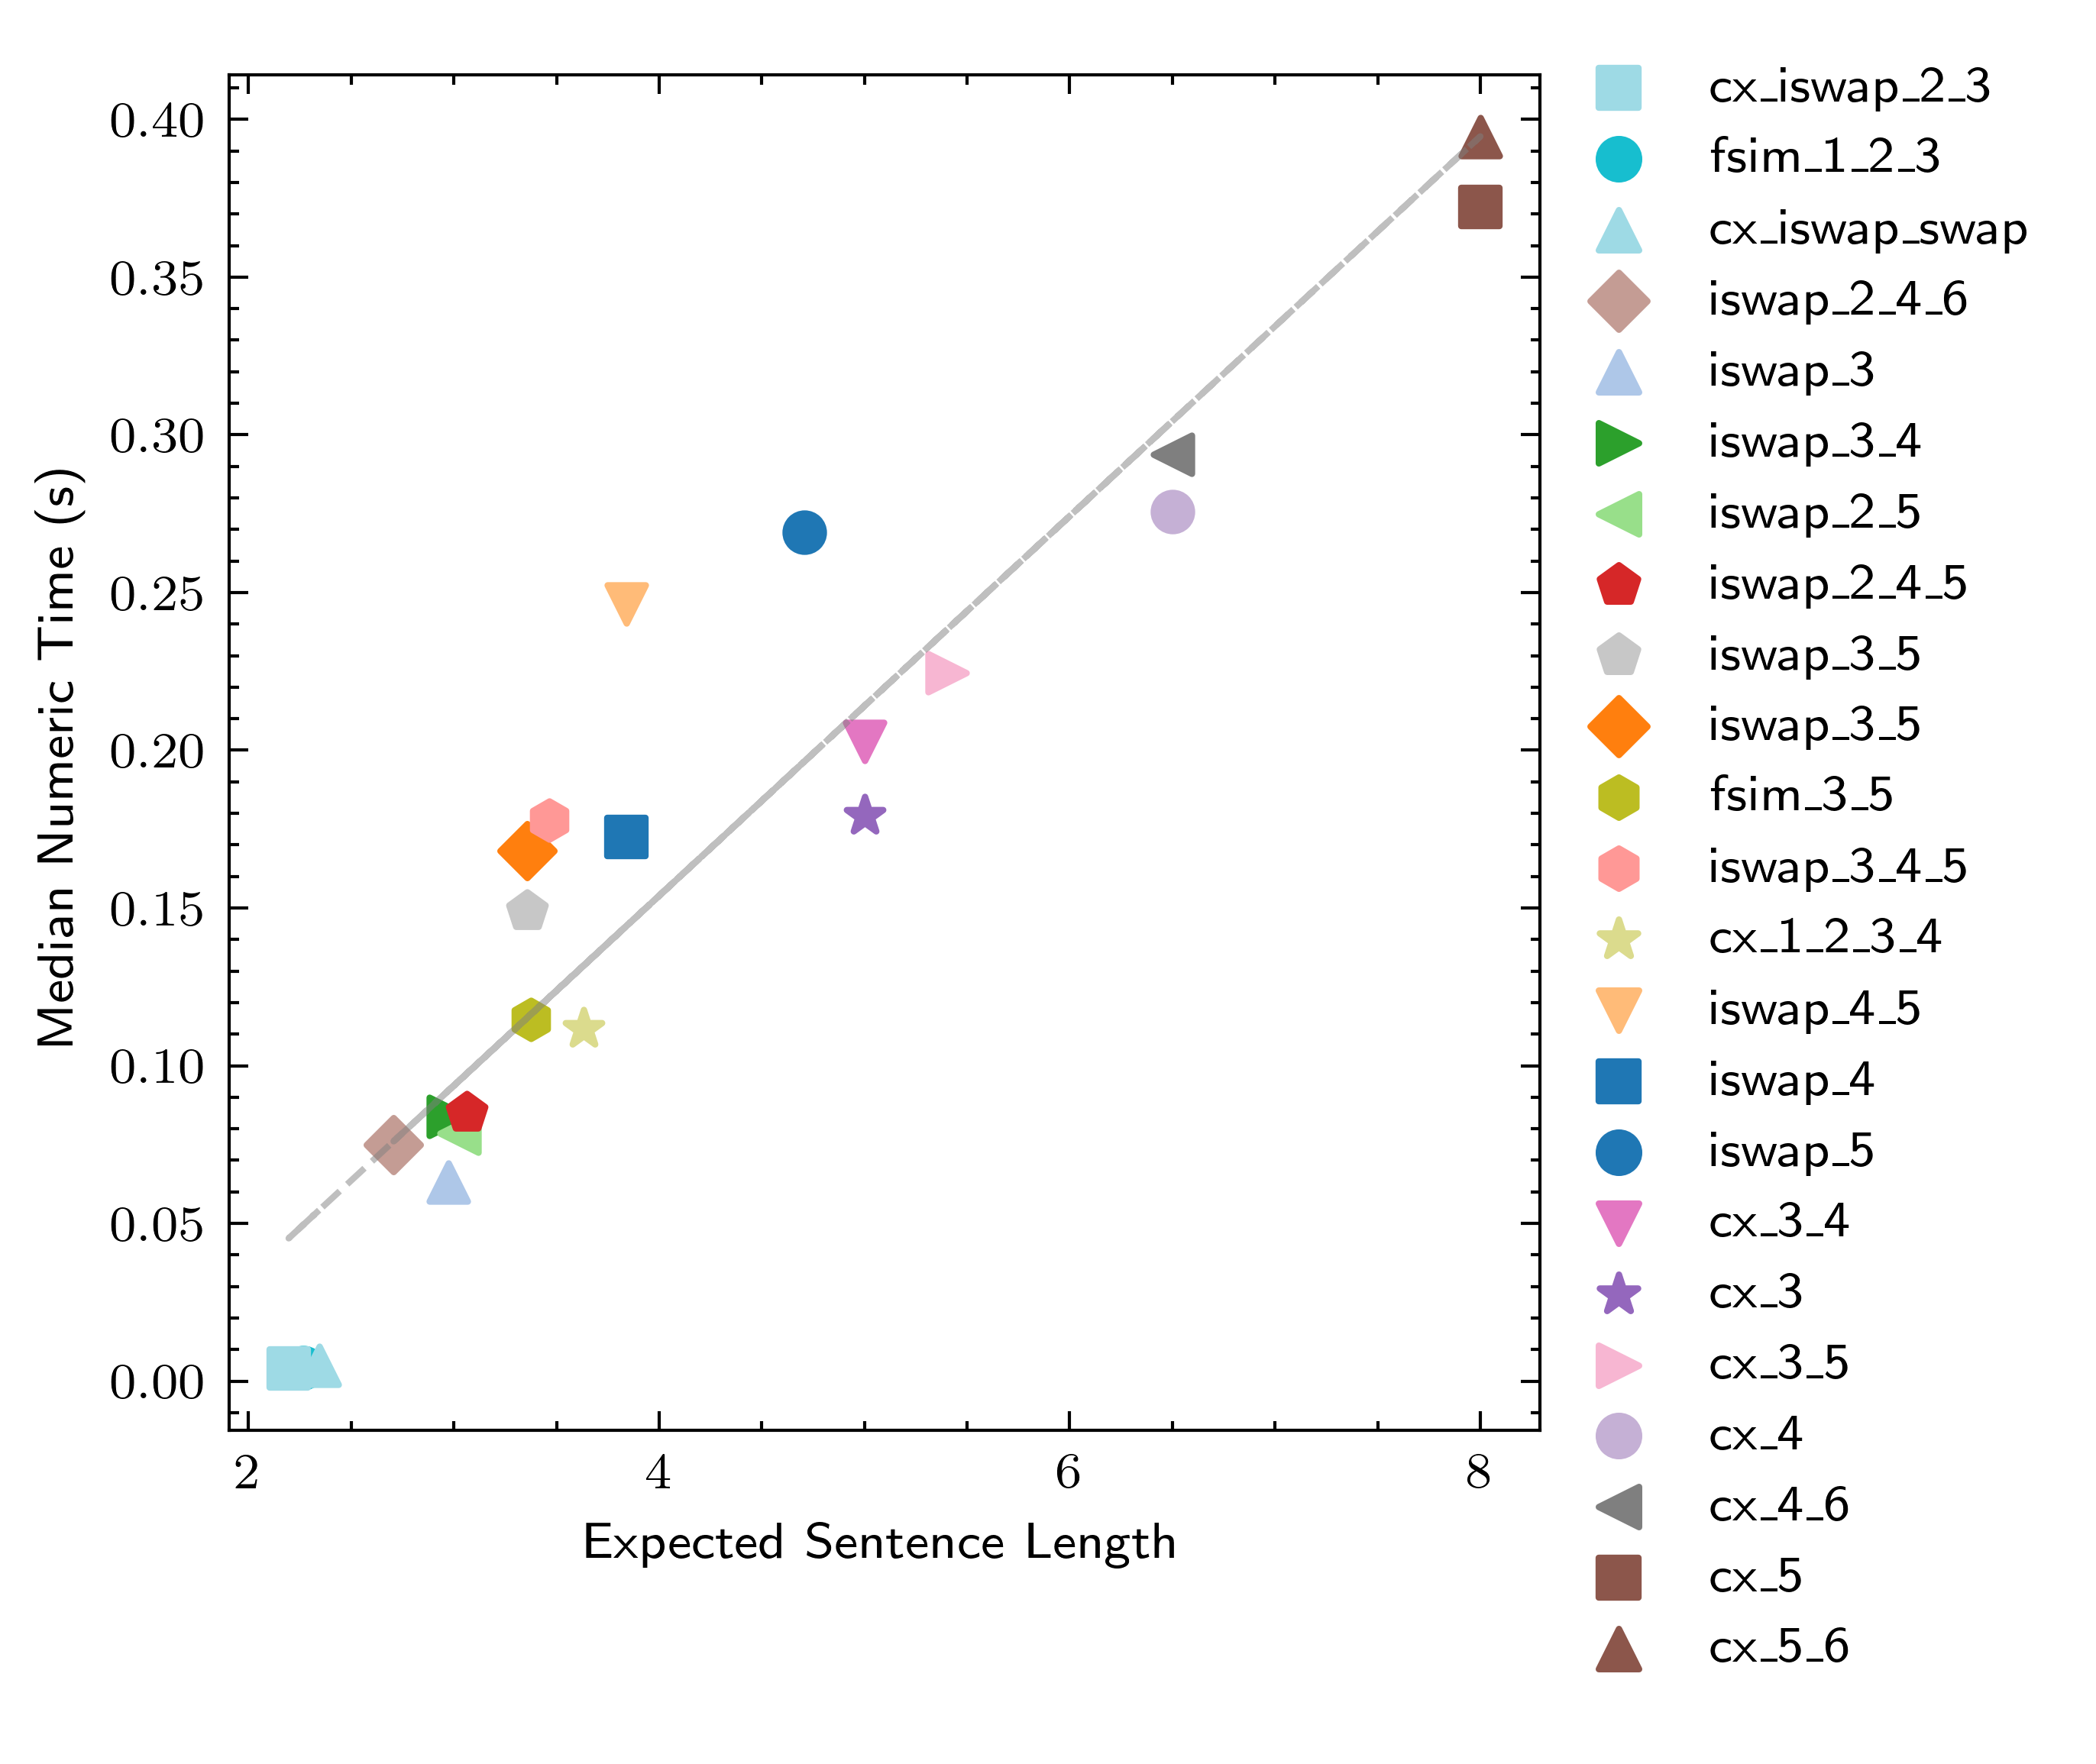

In [76]:
# === Process Timing Results (std, clipped at 0) ===
numeric_means = []
numeric_err_low = []
numeric_err_high = []

for r in results:
    valid_timings = [
        t["numeric"] for t in r["timings"] if isinstance(t, dict) and t["numeric"] != -1
    ]

    if len(valid_timings) == 0:
        numeric_means.append(np.nan)
        numeric_err_low.append(np.nan)
        numeric_err_high.append(np.nan)
        continue

    median = np.median(valid_timings)
    std = np.std(valid_timings)
    lower = max(median - std, 0)
    upper = median + std

    numeric_means.append(median)
    numeric_err_low.append(median - lower)
    numeric_err_high.append(upper - median)

# === Plot with Consistent ISA Markers and Colors ===
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    for i, name in enumerate(names):
        if np.isnan(numeric_means[i]):
            continue

        ax.scatter(
            depth[i],
            numeric_means[i],
            # yerr=[[numeric_err_low[i]], [numeric_err_high[i]]],
            # fmt=markers[i],
            color=colors[i],
            marker=markers[i],
            # markersize=6,
            # capsize=3,
            # ecolor="gray",
            # elinewidth=1,
            label=name,
        )
        # ax.annotate(name, (depth[i], numeric_means[i]), fontsize=7)

    ax.set_xlabel("Expected Sentence Length")
    ax.set_ylabel("Median Numeric Time (s)")

    # O(n) fit over valid entries
    valid_idx = [i for i, v in enumerate(numeric_means) if not np.isnan(v)]
    fit = np.poly1d(
        np.polyfit(np.array(depth)[valid_idx], np.array(numeric_means)[valid_idx], 1)
    )
    ax.plot(
        depth,
        fit(depth),
        linestyle="--",
        color="gray",
        label="O(n) fit",
        alpha=0.5,
    )
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper right",
        ncol=1,  # len(names),
        bbox_to_anchor=(1.3, 1.0),
    )

    fig.tight_layout()
plt.show()